<a href="https://colab.research.google.com/github/Priyall33/Pcos-Endometrosis-risk-model/blob/main/06_SHAP_Explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 06 — SHAP Explainability

This notebook uses SHAP (SHapley Additive exPlanations) to explain
why both models make the predictions they do — for both models
globally (overall patterns) and individually (per woman).

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os

drive.mount('/content/drive')
os.makedirs('outputs', exist_ok=True)

# Install SHAP
!pip install shap -q

import shap


Mounted at /content/drive


Load Data

In [2]:
import json

save_dir = '/content/drive/MyDrive/model_data/'

# Load Model 1 — NHANES hormone model
with open(f'{save_dir}model1_nhanes.pkl', 'rb') as f:
    model1 = pickle.load(f)


# Load Model 2 — BRFSS lifestyle model
with open(f'{save_dir}model2_brfss.pkl', 'rb') as f:
    model2 = pickle.load(f)


# Load model configs
with open(f'{save_dir}model1_config.json', 'r') as f:
    config1 = json.load(f)

with open(f'{save_dir}model2_config.json', 'r') as f:
    config2 = json.load(f)

# Load test data
X_test_nhanes = pd.read_csv(f'{save_dir}nhanes_X_test.csv')
y_test_nhanes = pd.read_csv(f'{save_dir}nhanes_y_test.csv').squeeze()
X_test_brfss  = pd.read_csv(f'{save_dir}brfss_X_test.csv')
y_test_brfss  = pd.read_csv(f'{save_dir}brfss_y_test.csv').squeeze()

print(f"\nEVERYTHING LOADED ")
print(f"Model 1 features : {model1.n_features_in_}")
print(f"Model 2 features : {model2.n_features_in_}")
print(f"NHANES test set  : {X_test_nhanes.shape}")
print(f"BRFSS test set   : {X_test_brfss.shape}")

# Sample for SHAP
nhanes_sample = X_test_nhanes.sample(500, random_state=42)
brfss_sample  = X_test_brfss.sample(500, random_state=42)

print(f"\nSHAP samples ready:")
print(f"  NHANES : {len(nhanes_sample)} rows")
print(f"  BRFSS  : {len(brfss_sample)} rows")



EVERYTHING LOADED 
Model 1 features : 11
Model 2 features : 13
NHANES test set  : (2269, 11)
BRFSS test set   : (45909, 13)

SHAP samples ready:
  NHANES : 500 rows
  BRFSS  : 500 rows


Compute shap values

In [3]:
explainer1 = shap.TreeExplainer(model1)
shap_values1 = explainer1.shap_values(nhanes_sample)


print(f"Shape: {shap_values1.shape}")
print(f"Rows: {shap_values1.shape[0]} women")
print(f"Cols: {shap_values1.shape[1]} features")

Shape: (500, 11)
Rows: 500 women
Cols: 11 features


SHAP - feature importance bar chart - which hormone features matter most - model 1

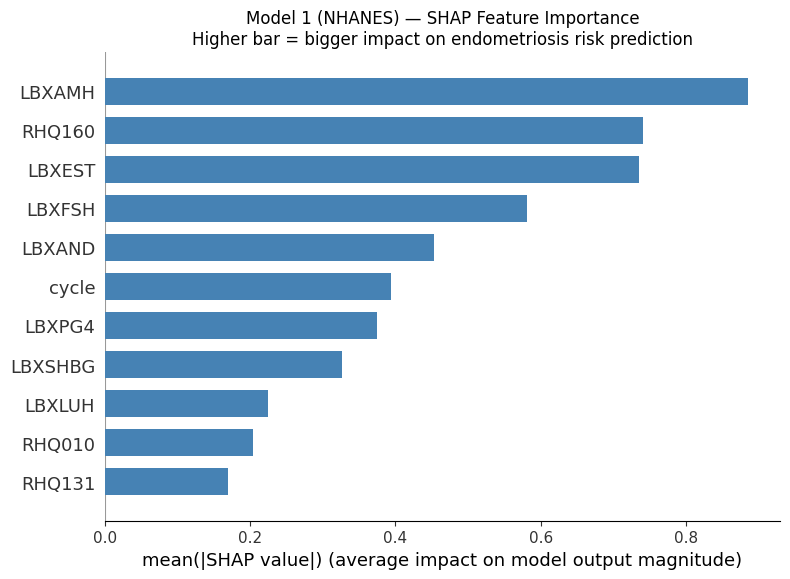

In [4]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values1,
    nhanes_sample,
    plot_type='bar',
    show=False,
    color='steelblue'
)
plt.title('Model 1 (NHANES) — SHAP Feature Importance\n'
          'Higher bar = bigger impact on endometriosis risk prediction',
          fontsize=12)
plt.tight_layout()
plt.savefig('outputs/model1_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()


SHAP Beeswarm plot - Model 1

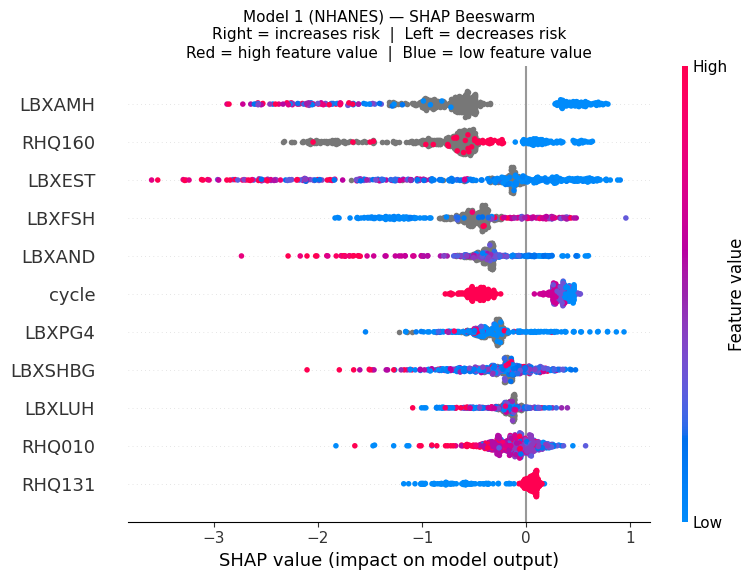

In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values1,
    nhanes_sample,
    show=False
)
plt.title('Model 1 (NHANES) — SHAP Beeswarm\n'
          'Right = increases risk  |  Left = decreases risk\n'
          'Red = high feature value  |  Blue = low feature value',
          fontsize=11)
plt.tight_layout()
plt.savefig('outputs/model1_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()


Individual prediction explanation - model 1

each bar shows how much feature pushed the prediction

Explaining prediction for woman #855
Actual diagnosis : Endometriosis positive
Model probability: 59.7% risk


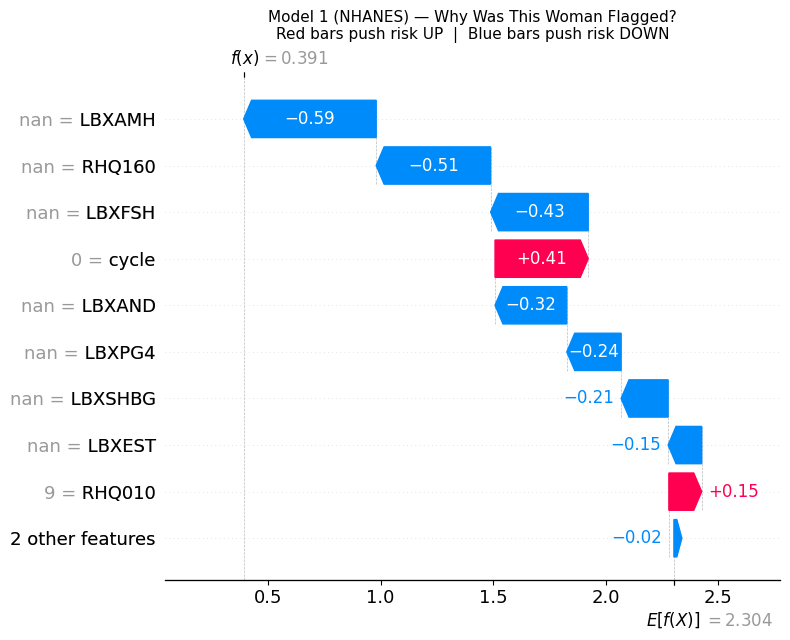

In [6]:
y_sample_nhanes = y_test_nhanes.loc[nhanes_sample.index]
high_risk_idx = y_sample_nhanes[y_sample_nhanes == 1].index

if len(high_risk_idx) > 0:
    idx = high_risk_idx[0]
    pos = nhanes_sample.index.get_loc(idx)

    prob = model1.predict_proba(
        nhanes_sample.iloc[[pos]]
    )[:,1][0]

    print(f"Explaining prediction for woman #{idx}")
    print(f"Actual diagnosis : Endometriosis positive")
    print(f"Model probability: {prob*100:.1f}% risk")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values1[pos],
            base_values=explainer1.expected_value,
            data=nhanes_sample.iloc[pos],
            feature_names=nhanes_sample.columns.tolist()
        ),
        show=False
    )
    plt.title('Model 1 (NHANES) — Why Was This Woman Flagged?\n'
              'Red bars push risk UP  |  Blue bars push risk DOWN',
              fontsize=11)
    plt.tight_layout()
    plt.savefig('outputs/model1_shap_waterfall.png',
                dpi=150, bbox_inches='tight')
    plt.show()


Compute shap values

In [7]:
explainer2 = shap.TreeExplainer(model2)
shap_values2 = explainer2.shap_values(brfss_sample)


print(f"Shape: {shap_values2.shape}")

Shape: (500, 13)


Feature Importance bar chart - model 2

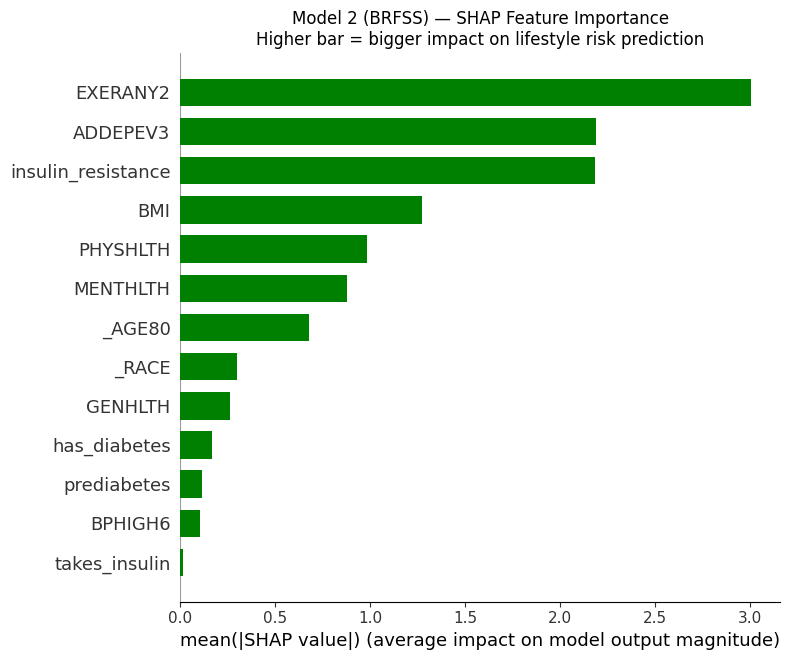

In [8]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values2,
    brfss_sample,
    plot_type='bar',
    show=False,
    color='green'
)
plt.title('Model 2 (BRFSS) — SHAP Feature Importance\n'
          'Higher bar = bigger impact on lifestyle risk prediction',
          fontsize=12)
plt.tight_layout()
plt.savefig('outputs/model2_shap_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()


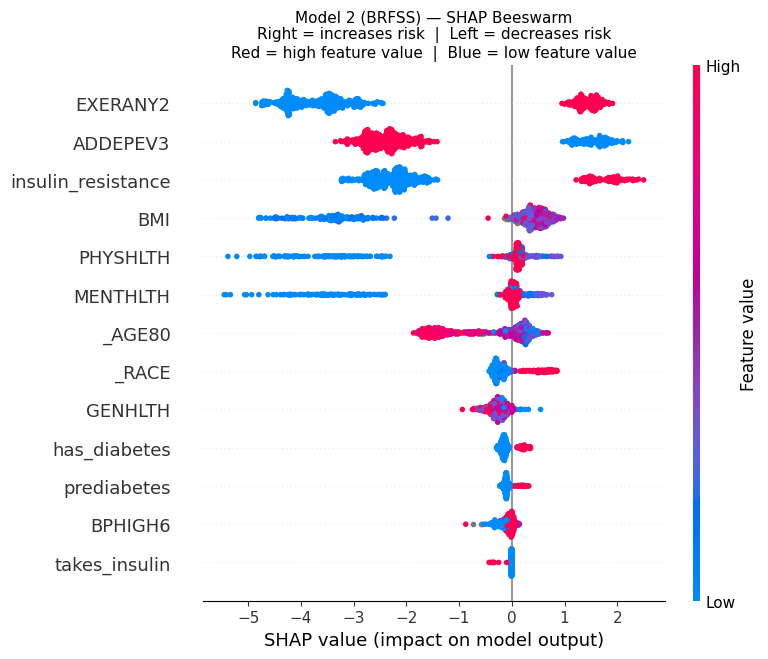

In [9]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values2,
    brfss_sample,
    show=False
)
plt.title('Model 2 (BRFSS) — SHAP Beeswarm\n'
          'Right = increases risk  |  Left = decreases risk\n'
          'Red = high feature value  |  Blue = low feature value',
          fontsize=11)
plt.tight_layout()
plt.savefig('outputs/model2_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()


Explaining prediction for woman #18410
Actual label     : High risk
Model probability: 99.7% risk


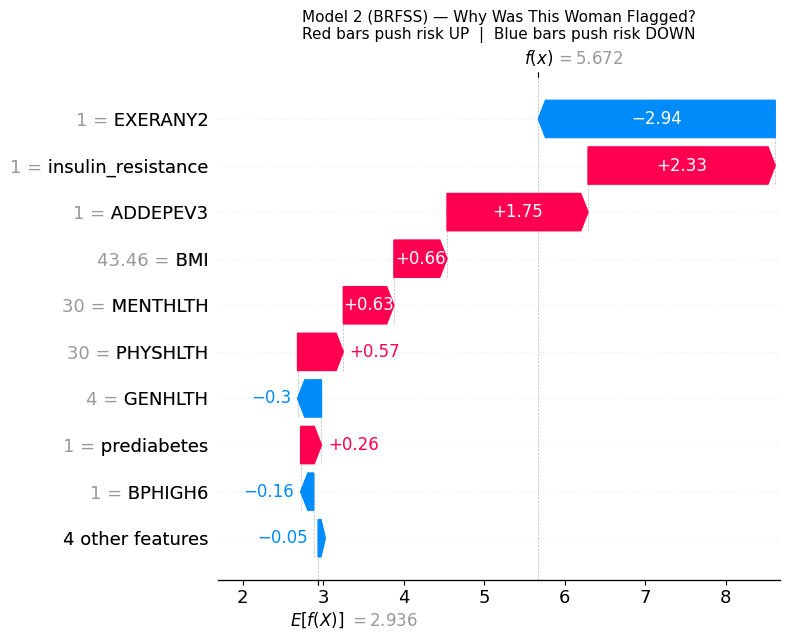

In [10]:
y_sample_brfss = y_test_brfss.loc[brfss_sample.index]
high_risk_idx2 = y_sample_brfss[y_sample_brfss == 1].index

if len(high_risk_idx2) > 0:
    idx2 = high_risk_idx2[0]
    pos2 = brfss_sample.index.get_loc(idx2)

    prob2 = model2.predict_proba(
        brfss_sample.iloc[[pos2]]
    )[:,1][0]

    print(f"Explaining prediction for woman #{idx2}")
    print(f"Actual label     : High risk")
    print(f"Model probability: {prob2*100:.1f}% risk")

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values2[pos2],
            base_values=explainer2.expected_value,
            data=brfss_sample.iloc[pos2],
            feature_names=brfss_sample.columns.tolist()
        ),
        show=False
    )
    plt.title('Model 2 (BRFSS) — Why Was This Woman Flagged?\n'
              'Red bars push risk UP  |  Blue bars push risk DOWN',
              fontsize=11)
    plt.tight_layout()
    plt.savefig('outputs/model2_shap_waterfall.png',
                dpi=150, bbox_inches='tight')
    plt.show()


In [11]:
def calculate_risk_score(hormone_data=None, lifestyle_data=None):

    """
    Calculate combined PCOS/endometriosis risk score

    Parameters
    ----------
    hormone_data   : dict — hormone values (Model 1)
                     Pass None if blood test not available
    lifestyle_data : dict — lifestyle values (Model 2)

    Returns
    -------
    score  : float 0-100
    level  : str Low/Medium/High Risk
    factors: list of top contributing features
    """

    scores   = []
    factors  = []

    #  Model 1 — hormone (if blood test available)
    if hormone_data is not None:
        h_df   = pd.DataFrame([hormone_data])
        h_prob = model1.predict_proba(h_df)[:,1][0]
        scores.append(h_prob)

        h_shap = explainer1.shap_values(h_df)[0]
        h_imp  = pd.Series(
            np.abs(h_shap),
            index=h_df.columns
        ).sort_values(ascending=False)

        for feat in h_imp.head(2).index:
            factors.append(f"Hormone: {feat}")

        print(f"Model 1 (Hormone) : {h_prob*100:.1f}% risk")

    #  Model 2 — lifestyle
    if lifestyle_data is not None:
        l_df   = pd.DataFrame([lifestyle_data])
        l_prob = model2.predict_proba(l_df)[:,1][0]
        scores.append(l_prob)

        l_shap = explainer2.shap_values(l_df)[0]
        l_imp  = pd.Series(
            np.abs(l_shap),
            index=l_df.columns
        ).sort_values(ascending=False)

        for feat in l_imp.head(2).index:
            factors.append(f"Lifestyle: {feat}")

        print(f"Model 2 (Lifestyle): {l_prob*100:.1f}% risk")

    # Combined score
    combined     = np.mean(scores) if scores else 0
    combined_pct = combined * 100

    if combined_pct < 30:
        level = "🟢 Low Risk"
        action = "Routine monitoring recommended"
    elif combined_pct < 60:
        level = "🟡 Medium Risk"
        action = "Discuss with your GP at next visit"
    else:
        level = "🔴 High Risk"
        action = "Schedule appointment with gynecologist"


    print(f"COMBINED RISK SCORE : {combined_pct:.1f} / 100")
    print(f"RISK LEVEL          : {level}")
    print(f"RECOMMENDED ACTION  : {action}")
    print(f"\nTop contributing factors:")
    for i, f in enumerate(factors[:3], 1):
        print(f"  {i}. {f}")


    return combined_pct, level, factors[:3]

# Test with example high risk woman
print("TEST — High risk woman (lifestyle data only, no blood test)")


example_lifestyle = {
    'BMI'              : 31.5,
    'insulin_resistance': 1,
    'takes_insulin'    : 0,
    'prediabetes'      : 1,
    'has_diabetes'     : 0,
    'BPHIGH6'          : 1,
    'GENHLTH'          : 4,
    'PHYSHLTH'         : 15,
    'MENTHLTH'         : 12,
    'ADDEPEV3'         : 1,
    'EXERANY2'         : 0,
    '_AGE80'           : 32,
    '_RACE'            : 1
}

score, level, factors = calculate_risk_score(
    lifestyle_data=example_lifestyle
)

TEST — High risk woman (lifestyle data only, no blood test)
Model 2 (Lifestyle): 99.5% risk
COMBINED RISK SCORE : 99.5 / 100
RISK LEVEL          : 🔴 High Risk
RECOMMENDED ACTION  : Schedule appointment with gynecologist

Top contributing factors:
  1. Lifestyle: EXERANY2
  2. Lifestyle: insulin_resistance
